In [1]:
from pathlib import Path

DATA_DIR    = Path("GYTS_CSVs")
CLEANED_DIR = DATA_DIR / "CLEANED"

import pandas as pd
import numpy as np

df = pd.read_csv(DATA_DIR / "GYTS_Bangladesh_National_2013.csv")

print(df.shape)
print(df[['CR1', 'CR2', 'CR7', 'CR19', 'CR35', 'CR39', 'CR40', 'FinalWgt', 'Stratum', 'PSU']].head(10))

(3245, 63)
   CR1  CR2  CR7  CR19  CR35  CR39  CR40   FinalWgt      Stratum  PSU
0  1.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
1  3.0  2.0  1.0   5.0   2.0   NaN   1.0  48.699926  201301001.0  1.0
2  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
3  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
4  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
5  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
6  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
7  4.0  2.0  1.0   NaN   NaN   NaN   NaN  48.699926  201301001.0  1.0
8  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0
9  4.0  2.0  1.0   5.0   2.0   1.0   1.0  48.699926  201301001.0  1.0


In [2]:
df = df[df['CR1'].isin([3, 4, 5])].copy()
print(f"Rows after age filter: {len(df)}")

df['CSMK'] = np.select(
    [df['CR7'] == 1,
     df['CR7'].isin([2, 3, 4, 5, 6, 7])],
    [0, 1],
    default=np.nan
)

df['SHS'] = np.select(
    [df['CR19'] == 1,
     df['CR19'].isin([2, 3, 4, 5])],
    [0, 1],
    default=np.nan
)

df['PROADV'] = np.select(
    [df['CR35'] == 2,
     df['CR35'] == 3],
    [1, 0],
    default=np.nan
)

df['SUSCEP'] = np.select(
    [(df['CR39'] == 1) & (df['CR40'] == 1),
     df['CR39'].notna() & df['CR40'].notna()],
    [0, 1],
    default=np.nan
)

df['COUNTRY'] = 'Bangladesh'
df['YEAR']    = 2013
df['REGION']  = 'SEARO'
df['WEIGHT']  = df['FinalWgt']

print("\nIndicator prevalences (rough, unweighted):")
for col in ['CSMK', 'SHS', 'PROADV', 'SUSCEP']:
    pct = df[col].mean() * 100
    n   = df[col].notna().sum()
    print(f"  {col}: {pct:.1f}%  (n={n})")

Rows after age filter: 3186

Indicator prevalences (rough, unweighted):
  CSMK: 1.6%  (n=3072)
  SHS: 34.2%  (n=3177)
  PROADV: 48.2%  (n=1876)
  SUSCEP: 12.5%  (n=3165)


In [3]:
print("Weighted vs Unweighted prevalences:")
for col in ['CSMK', 'SHS', 'PROADV', 'SUSCEP']:
    mask = df[col].notna()
    unweighted = df.loc[mask, col].mean() * 100
    weighted   = np.average(df.loc[mask, col], weights=df.loc[mask, 'WEIGHT']) * 100
    print(f"  {col}: unweighted={unweighted:.1f}%  weighted={weighted:.1f}%")

Weighted vs Unweighted prevalences:
  CSMK: unweighted=1.6%  weighted=2.1%
  SHS: unweighted=34.2%  weighted=31.1%
  PROADV: unweighted=48.2%  weighted=52.3%
  SUSCEP: unweighted=12.5%  weighted=13.8%


In [4]:
import os
os.makedirs(CLEANED_DIR, exist_ok=True)

In [5]:
df.to_csv(CLEANED_DIR / "Bangladesh_2013_clean.csv", index=False)
print("Saved.")

Saved.


In [6]:
never_user_mask = df['CR5'] == 2

df['SUSCEP'] = np.select(
    [(df['CR39'] == 1) & (df['CR40'] == 1) & never_user_mask,
     never_user_mask & df['CR39'].notna() & df['CR40'].notna()],
    [0, 1],
    default=np.nan
)

mask = df['SUSCEP'].notna()
weighted_suscep = np.average(df.loc[mask, 'SUSCEP'], weights=df.loc[mask, 'WEIGHT']) * 100
print(f"SUSCEP (corrected, weighted): {weighted_suscep:.1f}%")

SUSCEP (corrected, weighted): 10.8%


In [7]:
never = df[df['CR5'] == 2]
print("CR39 distribution (never users):")
print(never['CR39'].value_counts(dropna=False))
print("\nCR40 distribution (never users):")
print(never['CR40'].value_counts(dropna=False))
print("\nBoth CR39 and CR40 non-missing:", never[never['CR39'].notna() & never['CR40'].notna()].shape[0])
print("Either missing:", never[never['CR39'].isna() | never['CR40'].isna()].shape[0])

CR39 distribution (never users):
CR39
1.0    2678
2.0     101
3.0      61
4.0      21
NaN      11
Name: count, dtype: int64

CR40 distribution (never users):
CR40
1.0    2673
2.0     151
3.0      28
4.0      16
NaN       4
Name: count, dtype: int64

Both CR39 and CR40 non-missing: 2861
Either missing: 11


In [8]:
def recode_gyts(df, country, year, region):
    """
    Recode a single GYTS country dataframe into standardized indicators.
    Returns cleaned dataframe with CSMK, SHS, PROADV, SUSCEP columns.
    """
    df = df.copy()

    if 'CR1' not in df.columns:
        print(f"  SKIP {country}: no CR1 column")
        return None
    df = df[df['CR1'].isin([3, 4, 5])].copy()

    if len(df) < 50:
        print(f"  SKIP {country}: too few rows after age filter ({len(df)})")
        return None

    if 'CR7' in df.columns:
        df['CSMK'] = np.select(
            [df['CR7'] == 1, df['CR7'].isin([2,3,4,5,6,7])],
            [0, 1], default=np.nan
        )
    else:
        df['CSMK'] = np.nan

    if 'CR19' in df.columns:
        df['SHS'] = np.select(
            [df['CR19'] == 1, df['CR19'].isin([2,3,4,5])],
            [0, 1], default=np.nan
        )
    else:
        df['SHS'] = np.nan

    if 'CR35' in df.columns:
        df['PROADV'] = np.select(
            [df['CR35'] == 2, df['CR35'] == 3],
            [1, 0], default=np.nan
        )
    else:
        df['PROADV'] = np.nan

    if 'CR39' in df.columns and 'CR40' in df.columns and 'CR5' in df.columns:
        never = df['CR5'] == 2
        df['SUSCEP'] = np.select(
            [(df['CR39'] == 1) & (df['CR40'] == 1) & never,
              never & df['CR39'].notna() & df['CR40'].notna()],
            [0, 1], default=np.nan
        )
    else:
        df['SUSCEP'] = np.nan

    df['COUNTRY'] = country
    df['YEAR']    = year
    df['REGION']  = region
    df['WEIGHT']  = df['FinalWgt']

    return df[['COUNTRY', 'YEAR', 'REGION', 'WEIGHT', 'Stratum', 'PSU',
               'CR1', 'CR2', 'CSMK', 'SHS', 'PROADV', 'SUSCEP']]

In [9]:
import os
from pathlib import Path

CSV_DIR     = DATA_DIR
CLEANED_DIR.mkdir(exist_ok=True)

all_frames = []
errors     = []

for csv_path in sorted(CSV_DIR.glob("GYTS_*.csv")):
    parts       = csv_path.stem.split("_")
    year_str    = parts[-1].replace("-1", "").replace("_0", "")
    country     = "_".join(parts[1:-1])

    try:
        year = int(year_str[:4])
    except:
        errors.append(f"YEAR PARSE ERROR: {csv_path.name}")
        continue

    region_map = {
        'AFRO':  ['Algeria','Angola','Benin','Botswana','Burkina','Burundi','Cameroon',
                  'Central_African','Chad','Comoros','Congo','Cote','Democratic_Republic',
                  'Djibouti','Equatorial','Eritrea','Ethiopia','Gabon','Gambia','Ghana',
                  'Guinea','Kenya','Lesotho','Liberia','Libyan','Malawi','Mali','Mauritania',
                  'Mauritius','Mozambique','Namibia','Niger','Nigeria','Rwanda','Sao_Tome',
                  'Senegal','Seychelles','Sierra','Somalia','South_Africa','Swaziland',
                  'Tanzania','Togo','Uganda','Zambia','Zimbabwe'],
        'EMRO':  ['Bahrain','Egypt','Gaza','Iran','Iraq','Jordan','Kuwait','Lebanon',
                  'Libyan','Morocco','Oman','Pakistan','Saudi','Sudan','Syrian','Tunisia',
                  'United_Arab','West_Bank','Yemen','UNRWA'],
        'EURO':  ['Albania','Armenia','Azerbaijan','Belarus','Bosnia','Croatia','Cyprus',
                  'Czech','Estonia','Finland','Georgia','Greece','Hungary','Italy','Kazakhstan',
                  'Kosovo','Kyrgyzstan','Latvia','Lithuania','Moldova','Poland','Portugal',
                  'Romania','Russian','San_Marino','Serbia','Slovakia','Slovenia','Tajikistan',
                  'The_former','Turkey','Turkmenistan','Ukraine','Uzbekistan'],
        'PAHO':  ['Argentina','Bolivia','Brazil','Chile','Colombia','Cuba','Ecuador',
                  'El_Salvador','Nicaragua','Paraguay','Peru','St_Vincent','Suriname',
                  'Uruguay','Venezuela'],
        'SEARO': ['Bangladesh','Bhutan','India','Indonesia','Maldives','Myanmar','Nepal',
                  'Sri_Lanka','Thailand','East_Timor'],
        'WPRO':  ['Cambodia','China','Cook_Islands','Fiji','Guam','Hong_Kong','Laos',
                  'Macao','Malaysia','Marshall','Mongolia','New_Caledonia','New_Zealand',
                  'Niue','Northern_Mariana','Palau','Papua','Philippines','Samoa',
                  'Singapore','Solomon','Tokelau','Tonga','Vanuatu','Viet_Nam']
    }

    region = 'UNKNOWN'
    for reg, countries in region_map.items():
        if any(c in country for c in countries):
            region = reg
            break

    try:
        df_raw  = pd.read_csv(csv_path)
        df_clean = recode_gyts(df_raw, country, year, region)

        if df_clean is not None:
            all_frames.append(df_clean)
            print(f"✓ {country} {year} [{region}]  ({len(df_clean)} rows)")

    except Exception as e:
        errors.append(f"ERROR {csv_path.name}: {e}")

print(f"\n--- Done: {len(all_frames)} datasets processed, {len(errors)} errors ---")
for e in errors:
    print(" ", e)

  SKIP Algeria_Constantine: too few rows after age filter (0)
  SKIP Algeria_Oran: too few rows after age filter (0)
  SKIP Algeria_Setif: too few rows after age filter (0)
  SKIP Angola_Huambo: too few rows after age filter (0)
✓ Argentina_National 2018 [PAHO]  (1251 rows)
  SKIP Armenia_National: too few rows after age filter (0)
✓ Azerbaijan_National 2016 [EURO]  (2122 rows)
✓ Bahrain_National 2015 [EMRO]  (2465 rows)
  SKIP Bangladesh_Dhaka: too few rows after age filter (0)
✓ Bangladesh_National 2013 [SEARO]  (3186 rows)
✓ Belarus_National_2021 0 [EURO]  (2683 rows)
  SKIP Benin_Atlantique_Littoral: too few rows after age filter (0)
  SKIP Benin_Borgou_Alibori: too few rows after age filter (0)
  SKIP Bhutan_National: no CR1 column
  SKIP Bolivia_El-Alto: too few rows after age filter (0)
✓ Bolivia_National 2018 [PAHO]  (3782 rows)
  SKIP Bosnia_and_Herzegovina_Federation_of_Bosnia_and_Herzegovina: too few rows after age filter (0)
  SKIP Bosnia_and_Herzegovina_Republic_of_Srpska:

In [10]:
test = pd.read_csv(DATA_DIR / "GYTS_Algeria_Constantine_2007.csv")
print("Columns:", list(test.columns[:10]))
print("\nFirst age-like column values:")
print(test.iloc[:, 0].value_counts().head(10))

thai = pd.read_csv(DATA_DIR / "GYTS_Thailand_National_2022.csv")
print("\nThailand columns:", [c for c in thai.columns if 'wgt' in c.lower() or 'weight' in c.lower() or 'CR1' in c])
print("Thailand CR1 values:", thai['CR1'].value_counts().head(10) if 'CR1' in thai.columns else "NO CR1")

Columns: ['FinalWgt', 'CR1', 'CR2', 'CR3', 'CR4', 'DZR5', 'DZR6', 'DZR7', 'DZR8', 'DZR9']

First age-like column values:
FinalWgt
21.598235    31
24.069479    26
16.907923    26
22.651808    25
25.188990    25
19.408683    25
19.408683    24
21.598235    24
19.408683    24
26.325993    23
Name: count, dtype: int64

Thailand columns: ['GRPwgt', 'CR1', 'CR10', 'CR11', 'CR12', 'CR13', 'CR14', 'CR15', 'CR16', 'CR17', 'CR18', 'CR19']
Thailand CR1 values: CR1
3.0    2671
4.0    2535
5.0    1546
2.0     964
6.0     100
7.0      21
1.0       7
Name: count, dtype: int64


In [11]:
def recode_gyts(df, country, year, region):
    df = df.copy()

    if 'CR1' not in df.columns:
        print(f"  SKIP {country}: no CR1 column")
        return None

    cr1_vals = df['CR1'].dropna().unique()
    if any(v in cr1_vals for v in [13, 14, 15]):
        df = df[df['CR1'].isin([13, 14, 15])].copy()
    else:
        df = df[df['CR1'].isin([3, 4, 5])].copy()

    if len(df) < 50:
        print(f"  SKIP {country}: too few rows after age filter ({len(df)})")
        return None

    weight_col = None
    for col in ['FinalWgt', 'finalwgt', 'GRPwgt', 'WEIGHT', 'Weight', 'W']:
        if col in df.columns:
            weight_col = col
            break
    if weight_col is None:
        print(f"  SKIP {country}: no weight column found")
        return None

    if 'CR7' in df.columns:
        df['CSMK'] = np.select(
            [df['CR7'] == 1, df['CR7'].isin([2,3,4,5,6,7])],
            [0, 1], default=np.nan
        )
    else:
        df['CSMK'] = np.nan

    if 'CR19' in df.columns:
        df['SHS'] = np.select(
            [df['CR19'] == 1, df['CR19'].isin([2,3,4,5])],
            [0, 1], default=np.nan
        )
    else:
        df['SHS'] = np.nan

    if 'CR35' in df.columns:
        df['PROADV'] = np.select(
            [df['CR35'] == 2, df['CR35'] == 3],
            [1, 0], default=np.nan
        )
    else:
        df['PROADV'] = np.nan

    if 'CR39' in df.columns and 'CR40' in df.columns and 'CR5' in df.columns:
        never = df['CR5'] == 2
        df['SUSCEP'] = np.select(
            [(df['CR39'] == 1) & (df['CR40'] == 1) & never,
              never & df['CR39'].notna() & df['CR40'].notna()],
            [0, 1], default=np.nan
        )
    else:
        df['SUSCEP'] = np.nan

    df['COUNTRY'] = country
    df['YEAR']    = year
    df['REGION']  = region
    df['WEIGHT']  = df[weight_col]

    return df[['COUNTRY', 'YEAR', 'REGION', 'WEIGHT', 'Stratum', 'PSU',
               'CR1', 'CR2', 'CSMK', 'SHS', 'PROADV', 'SUSCEP']]

In [12]:
test = pd.read_csv(DATA_DIR / "GYTS_Algeria_Constantine_2007.csv")
print("Columns:", list(test.columns[:10]))
print("\nFirst age-like column values:")
print(test.iloc[:, 0].value_counts().head(10))

thai = pd.read_csv(DATA_DIR / "GYTS_Thailand_National_2022.csv")
print("\nThailand columns:", [c for c in thai.columns if 'wgt' in c.lower() or 'weight' in c.lower() or 'CR1' in c])
print("Thailand CR1 values:", thai['CR1'].value_counts().head(10) if 'CR1' in thai.columns else "NO CR1")

Columns: ['FinalWgt', 'CR1', 'CR2', 'CR3', 'CR4', 'DZR5', 'DZR6', 'DZR7', 'DZR8', 'DZR9']

First age-like column values:
FinalWgt
21.598235    31
24.069479    26
16.907923    26
22.651808    25
25.188990    25
19.408683    25
19.408683    24
21.598235    24
19.408683    24
26.325993    23
Name: count, dtype: int64

Thailand columns: ['GRPwgt', 'CR1', 'CR10', 'CR11', 'CR12', 'CR13', 'CR14', 'CR15', 'CR16', 'CR17', 'CR18', 'CR19']
Thailand CR1 values: CR1
3.0    2671
4.0    2535
5.0    1546
2.0     964
6.0     100
7.0      21
1.0       7
Name: count, dtype: int64


In [13]:
def recode_gyts(df, country, year, region):
    df = df.copy()

    if 'CR1' not in df.columns:
        print(f"  SKIP {country}: no CR1 column")
        return None

    cr1_vals = df['CR1'].dropna().unique()
    if any(v in cr1_vals for v in [13, 14, 15]):
        df = df[df['CR1'].isin([13, 14, 15])].copy()
    else:
        df = df[df['CR1'].isin([3, 4, 5])].copy()

    if len(df) < 50:
        print(f"  SKIP {country}: too few rows after age filter ({len(df)})")
        return None

    weight_col = None
    for col in ['FinalWgt', 'finalwgt', 'GRPwgt', 'WEIGHT', 'Weight', 'W']:
        if col in df.columns:
            weight_col = col
            break
    if weight_col is None:
        print(f"  SKIP {country}: no weight column found")
        return None

    if 'CR7' in df.columns:
        df['CSMK'] = np.select(
            [df['CR7'] == 1, df['CR7'].isin([2,3,4,5,6,7])],
            [0, 1], default=np.nan
        )
    else:
        df['CSMK'] = np.nan

    if 'CR19' in df.columns:
        df['SHS'] = np.select(
            [df['CR19'] == 1, df['CR19'].isin([2,3,4,5])],
            [0, 1], default=np.nan
        )
    else:
        df['SHS'] = np.nan

    if 'CR35' in df.columns:
        df['PROADV'] = np.select(
            [df['CR35'] == 2, df['CR35'] == 3],
            [1, 0], default=np.nan
        )
    else:
        df['PROADV'] = np.nan

    if 'CR39' in df.columns and 'CR40' in df.columns and 'CR5' in df.columns:
        never = df['CR5'] == 2
        df['SUSCEP'] = np.select(
            [(df['CR39'] == 1) & (df['CR40'] == 1) & never,
              never & df['CR39'].notna() & df['CR40'].notna()],
            [0, 1], default=np.nan
        )
    else:
        df['SUSCEP'] = np.nan

    df['COUNTRY'] = country
    df['YEAR']    = year
    df['REGION']  = region
    df['WEIGHT']  = df[weight_col]

    return df[['COUNTRY', 'YEAR', 'REGION', 'WEIGHT', 'Stratum', 'PSU',
               'CR1', 'CR2', 'CSMK', 'SHS', 'PROADV', 'SUSCEP']]

In [14]:
import os
from pathlib import Path

CSV_DIR     = DATA_DIR
CLEANED_DIR.mkdir(exist_ok=True)

all_frames = []
errors     = []

for csv_path in sorted(CSV_DIR.glob("GYTS_*.csv")):
    parts       = csv_path.stem.split("_")
    year_str    = parts[-1].replace("-1", "").replace("_0", "")
    country     = "_".join(parts[1:-1])

    try:
        year = int(year_str[:4])
    except:
        errors.append(f"YEAR PARSE ERROR: {csv_path.name}")
        continue

    region_map = {
        'AFRO':  ['Algeria','Angola','Benin','Botswana','Burkina','Burundi','Cameroon',
                  'Central_African','Chad','Comoros','Congo','Cote','Democratic_Republic',
                  'Djibouti','Equatorial','Eritrea','Ethiopia','Gabon','Gambia','Ghana',
                  'Guinea','Kenya','Lesotho','Liberia','Libyan','Malawi','Mali','Mauritania',
                  'Mauritius','Mozambique','Namibia','Niger','Nigeria','Rwanda','Sao_Tome',
                  'Senegal','Seychelles','Sierra','Somalia','South_Africa','Swaziland',
                  'Tanzania','Togo','Uganda','Zambia','Zimbabwe'],
        'EMRO':  ['Bahrain','Egypt','Gaza','Iran','Iraq','Jordan','Kuwait','Lebanon',
                  'Libyan','Morocco','Oman','Pakistan','Saudi','Sudan','Syrian','Tunisia',
                  'United_Arab','West_Bank','Yemen','UNRWA'],
        'EURO':  ['Albania','Armenia','Azerbaijan','Belarus','Bosnia','Croatia','Cyprus',
                  'Czech','Estonia','Finland','Georgia','Greece','Hungary','Italy','Kazakhstan',
                  'Kosovo','Kyrgyzstan','Latvia','Lithuania','Moldova','Poland','Portugal',
                  'Romania','Russian','San_Marino','Serbia','Slovakia','Slovenia','Tajikistan',
                  'The_former','Turkey','Turkmenistan','Ukraine','Uzbekistan'],
        'PAHO':  ['Argentina','Bolivia','Brazil','Chile','Colombia','Cuba','Ecuador',
                  'El_Salvador','Nicaragua','Paraguay','Peru','St_Vincent','Suriname',
                  'Uruguay','Venezuela'],
        'SEARO': ['Bangladesh','Bhutan','India','Indonesia','Maldives','Myanmar','Nepal',
                  'Sri_Lanka','Thailand','East_Timor'],
        'WPRO':  ['Cambodia','China','Cook_Islands','Fiji','Guam','Hong_Kong','Laos',
                  'Macao','Malaysia','Marshall','Mongolia','New_Caledonia','New_Zealand',
                  'Niue','Northern_Mariana','Palau','Papua','Philippines','Samoa',
                  'Singapore','Solomon','Tokelau','Tonga','Vanuatu','Viet_Nam']
    }

    region = 'UNKNOWN'
    for reg, countries in region_map.items():
        if any(c in country for c in countries):
            region = reg
            break

    try:
        df_raw  = pd.read_csv(csv_path)
        df_clean = recode_gyts(df_raw, country, year, region)

        if df_clean is not None:
            all_frames.append(df_clean)
            print(f"✓ {country} {year} [{region}]  ({len(df_clean)} rows)")

    except Exception as e:
        errors.append(f"ERROR {csv_path.name}: {e}")

print(f"\n--- Done: {len(all_frames)} datasets processed, {len(errors)} errors ---")
for e in errors:
    print(" ", e)

  SKIP Algeria_Constantine: too few rows after age filter (0)
  SKIP Algeria_Oran: too few rows after age filter (0)
  SKIP Algeria_Setif: too few rows after age filter (0)
  SKIP Angola_Huambo: too few rows after age filter (0)
✓ Argentina_National 2018 [PAHO]  (1251 rows)
  SKIP Armenia_National: too few rows after age filter (0)
✓ Azerbaijan_National 2016 [EURO]  (2122 rows)
✓ Bahrain_National 2015 [EMRO]  (2465 rows)
  SKIP Bangladesh_Dhaka: too few rows after age filter (0)
✓ Bangladesh_National 2013 [SEARO]  (3186 rows)
✓ Belarus_National_2021 0 [EURO]  (2683 rows)
  SKIP Benin_Atlantique_Littoral: too few rows after age filter (0)
  SKIP Benin_Borgou_Alibori: too few rows after age filter (0)
  SKIP Bhutan_National: no CR1 column
  SKIP Bolivia_El-Alto: too few rows after age filter (0)
✓ Bolivia_National 2018 [PAHO]  (3782 rows)
  SKIP Bosnia_and_Herzegovina_Federation_of_Bosnia_and_Herzegovina: too few rows after age filter (0)
  SKIP Bosnia_and_Herzegovina_Republic_of_Srpska:

In [15]:
algeria = pd.read_csv(DATA_DIR / "GYTS_Algeria_Constantine_2007.csv")
print("Algeria CR1 unique values:", sorted(algeria['CR1'].dropna().unique()))

india = pd.read_csv(DATA_DIR / "GYTS_India_Assam_2000.csv")
print("\nIndia columns:", list(india.columns[:15]))
print("India potential age columns:")
for col in india.columns[:15]:
    print(f"  {col}:", sorted(india[col].dropna().unique()[:8]))

Algeria CR1 unique values: [np.float64(1.0), np.float64(2.0)]

India columns: ['finalwgt', 'INR1', 'INR2', 'INR3', 'INR4', 'INR5', 'INR6', 'INR7', 'CR4', 'INR9', 'INR10', 'INR11', 'INR12', 'INR13', 'INR14']
India potential age columns:
  finalwgt: [np.float64(229.6604881053627), np.float64(272.82888757363986), np.float64(282.0630960763531), np.float64(295.5440528758614), np.float64(387.7684958961464), np.float64(400.8929680652528), np.float64(420.0532937473171), np.float64(455.419380782852)]
  INR1: [np.float64(1.0), np.float64(2.0)]
  INR2: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  INR3: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
  INR4: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
  INR5: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  INR6: [np.floa

In [16]:
global_df = pd.concat(all_frames, ignore_index=True)

print(f"Global dataset shape: {global_df.shape}")
print(f"\nBy region:")
print(global_df.groupby('REGION')['COUNTRY'].nunique().sort_values(ascending=False))
print(f"\nYear range: {global_df['YEAR'].min()} – {global_df['YEAR'].max()}")
print(f"\nIndicator non-missing rates:")
for col in ['CSMK', 'SHS', 'PROADV', 'SUSCEP']:
    pct = global_df[col].notna().mean() * 100
    print(f"  {col}: {pct:.1f}%")

Global dataset shape: (364219, 12)

By region:
REGION
EURO       32
EMRO       18
AFRO       15
PAHO       13
WPRO       10
SEARO       7
UNKNOWN     3
Name: COUNTRY, dtype: int64

Year range: 0 – 2023

Indicator non-missing rates:
  CSMK: 94.4%
  SHS: 97.8%
  PROADV: 73.6%
  SUSCEP: 68.3%


In [17]:
print(global_df[global_df['YEAR'] == 0]['COUNTRY'].unique())

<StringArray>
[         'Belarus_National_2021',          'Ecuador_National_2016',
 'Papua_New_Guinea_National_2016',    'Philippines_National_2019_0',
         'Portugal_National_2013',          'Senegal_National_2020',
          'Uruguay_National_2019']
Length: 7, dtype: str


In [18]:
def fix_year(country):
    import re
    matches = re.findall(r'\d{4}', country)
    if matches:
        return int(matches[-1])
    return None

mask = global_df['YEAR'] == 0
global_df.loc[mask, 'YEAR'] = global_df.loc[mask, 'COUNTRY'].apply(fix_year)

print("Years after fix:")
print(global_df[global_df['COUNTRY'].isin(['Belarus_National_2021', 'Ecuador_National_2016'])][['COUNTRY','YEAR']].drop_duplicates())
print(f"\nYear range: {global_df['YEAR'].min()} – {global_df['YEAR'].max()}")

Years after fix:
                     COUNTRY  YEAR
9024   Belarus_National_2021  2021
41691  Ecuador_National_2016  2016

Year range: 2012 – 2023


In [19]:
region_fixes = {
    'Bulgaria_National': 'EURO',
    'Cape_Verde_National': 'AFRO',
    'Korea_Republic_of_National': 'WPRO'
}
for country_partial, region in region_fixes.items():
    mask = global_df['COUNTRY'].str.contains(country_partial)
    global_df.loc[mask, 'REGION'] = region

print("Region counts after fix:")
print(global_df.groupby('REGION')['COUNTRY'].nunique().sort_values(ascending=False))

Region counts after fix:
REGION
EURO     33
EMRO     18
AFRO     16
PAHO     13
WPRO     11
SEARO     7
Name: COUNTRY, dtype: int64


In [ ]:
print("Region counts after fix:")
print(global_df.groupby('REGION')['COUNTRY'].nunique().sort_values(ascending=False))

print("\nOldest surveys:")
print(global_df[['COUNTRY','YEAR']].drop_duplicates().sort_values('YEAR').head(10))

Region counts after fix:
REGION
EURO     33
EMRO     18
AFRO     16
PAHO     13
WPRO     11
SEARO     7
Name: COUNTRY, dtype: int64

Oldest surveys:
                              COUNTRY  YEAR
50420                Finland_National  2012
5838              Bangladesh_National  2013
38677               Djibouti_National  2013
63166                 Greece_National  2013
159953         Portugal_National_2013  2013
124922            Mozambique_National  2013
82211      Korea_Republic_of_National  2013
80885                  Kenya_National  2013
331447  United_Arab_Emirates_National  2013
338700    UNRWA_Lebanon_UNRWA_Lebanon  2013


In [21]:
global_df.to_csv(CLEANED_DIR / "global_pooled.csv", index=False)

print(f"Saved global_pooled.csv")
print(f"  {len(global_df):,} rows")
print(f"  {global_df['COUNTRY'].nunique()} countries")
print(f"  {global_df['REGION'].nunique()} WHO regions")
print(f"  Years: {global_df['YEAR'].min()} – {global_df['YEAR'].max()}")

Saved global_pooled.csv
  364,219 rows
  98 countries
  6 WHO regions
  Years: 2012 – 2023


In [1]:
import pandas as pd
import numpy as np

global_df = pd.read_csv(CLEANED_DIR / "global_pooled.csv")
print(f"Loaded: {len(global_df):,} rows, {global_df['COUNTRY'].nunique()} countries")

Loaded: 364,219 rows, 98 countries


In [2]:
pip install samplics

   ---------------------------------------- 0.0/836.9 kB ? eta -:--:--
   ---------------------------------------- 836.9/836.9 kB 23.1 MB/s  0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   ------- -------------------------------- 9.7/52.7 MB 47.0 MB/s eta 0:00:01
   -------------- ------------------------- 18.6/52.7 MB 44.1 MB/s eta 0:00:01
   --------------------- ------------------ 28.8/52.7 MB 45.6 MB/s eta 0:00:01
   ----------------------------- ---------- 39.1/52.7 MB 46.0 MB/s eta 0:00:01
   ------------------------------------ --- 48.5/52.7 MB 46.2 MB/s eta 0:00:01
   ---------------------------------------- 52.7/52.7 MB 44.0 MB/s  0:00:01
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ------------- -------------------------- 9.2/28.0 MB 47.3 MB/s eta 0:00:01
   --------------------------- ------------ 19.4/28.0 MB 47.3 MB/s eta 0:00:01
   ---------------------------------------  27.8/28.0 MB 47.2 MB/s eta 0:00:01
   --

In [3]:
import pandas as pd
import numpy as np

global_df = pd.read_csv(CLEANED_DIR / "global_pooled.csv")
print(f"Loaded: {len(global_df):,} rows, {global_df['COUNTRY'].nunique()} countries")

Loaded: 364,219 rows, 98 countries


In [5]:
help(TaylorEstimator.__init__)

Help on function __init__ in module samplics.estimation.expansion:

__init__(
    self,
    param: PopParam,
    alpha: float = 0.05,
    rand_seed: Optional[int] = None,
    ciprop_method: Optional[str] = 'logit'
) -> None
    Initializes the instance



In [6]:
from samplics.utils.types import PopParam
print(list(PopParam))

[<PopParam.count: 'Count'>, <PopParam.mean: 'Mean'>, <PopParam.total: 'Total'>, <PopParam.prop: 'Proportion'>, <PopParam.ratio: 'Ratio'>, <PopParam.median: 'Median'>]


In [7]:
from samplics.estimation import TaylorEstimator
from samplics.utils.types import PopParam

estimator = TaylorEstimator(param=PopParam.prop)
result = estimator.estimate(
    y=bgd['CSMK'],
    samp_weight=bgd['WEIGHT'],
    stratum=bgd['Stratum'],
    psu=bgd['PSU']
)

print("Proper survey-design estimate:")
print(result)

Proper survey-design estimate:
None


In [8]:
print(dir(estimator))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_compute_influence_function', '_degree_of_freedom', '_estimate', '_estimate_density', '_get_point', '_get_point_d', '_get_variance', '_score_variable', '_taylor_variance', '_variance_stratum_between', '_variance_stratum_within', '_weighted_quantile', 'alpha', 'as_factor', 'by', 'ciprop_method', 'coef_var', 'covariance', 'deff', 'degree_of_freedom', 'domains', 'estimate', 'fpc', 'lower_ci', 'method', 'nb_psus', 'nb_strata', 'param', 'point_est', 'q_method', 'rand_seed', 'single_psu_strata', 'stderror', 'strata', 'to_dataframe', 'upper_ci', 'variance']


In [9]:
print(estimator.to_dataframe())

          _param  _level  _estimate  _stderror      _lci      _uci       _cv
0  PopParam.prop     0.0   0.978636   0.008633  0.951466  0.990744  0.008821
1  PopParam.prop     1.0   0.021364   0.008633  0.009256  0.048534  0.404069


In [10]:
def weighted_estimate(df, indicator, alpha=0.05):
    """Compute a survey-weighted point estimate + 95% CI for a binary indicator."""
    d = df.dropna(subset=[indicator])
    estimator = TaylorEstimator(param=PopParam.prop, alpha=alpha)
    estimator.estimate(
        y=d[indicator],
        samp_weight=d['WEIGHT'],
        stratum=d['Stratum'],
        psu=d['PSU']
    )
    res = estimator.to_dataframe()
    row = res[res['_level'] == 1.0].iloc[0]
    return {
        'indicator': indicator,
        'n': len(d),
        'estimate_pct': row['_estimate'] * 100,
        'lci_pct': row['_lci'] * 100,
        'uci_pct': row['_uci'] * 100,
        'cv': row['_cv']
    }

for ind in ['CSMK', 'SHS', 'PROADV', 'SUSCEP']:
    result = weighted_estimate(bgd, ind)
    print(f"{result['indicator']}: {result['estimate_pct']:.1f}% "
          f"(95% CI: {result['lci_pct']:.1f}–{result['uci_pct']:.1f}%, n={result['n']})")

CSMK: 2.1% (95% CI: 0.9–4.9%, n=3072)
SHS: 27.9% (95% CI: 23.0–33.5%, n=3063)
PROADV: 51.4% (95% CI: 42.0–60.7%, n=1802)
SUSCEP: 10.4% (95% CI: 7.3–14.4%, n=2830)


In [11]:
results = []

for country in global_df['COUNTRY'].unique():
    sub = global_df[global_df['COUNTRY'] == country]

    for year in sub['YEAR'].unique():
        country_year = sub[sub['YEAR'] == year]
        region = country_year['REGION'].iloc[0]

        for ind in ['CSMK', 'SHS', 'PROADV', 'SUSCEP']:
            try:
                est = weighted_estimate(country_year, ind)
                results.append({
                    'country': country,
                    'year': year,
                    'region': region,
                    **est
                })
            except Exception as e:
                results.append({
                    'country': country, 'year': year, 'region': region,
                    'indicator': ind, 'n': None, 'estimate_pct': None,
                    'lci_pct': None, 'uci_pct': None, 'cv': None
                })

results_df = pd.DataFrame(results)
print(f"Total estimates computed: {len(results_df)}")
print(f"\nFailed estimates: {results_df['estimate_pct'].isna().sum()}")
print("\nSample of results:")
print(results_df.head(10))

Total estimates computed: 392

Failed estimates: 89

Sample of results:
               country  year region indicator       n  estimate_pct  \
0   Argentina_National  2018   PAHO      CSMK  1219.0     17.954716   
1   Argentina_National  2018   PAHO       SHS  1236.0     35.337687   
2   Argentina_National  2018   PAHO    PROADV  1059.0     41.764038   
3   Argentina_National  2018   PAHO    SUSCEP   765.0     28.037619   
4  Azerbaijan_National  2016   EURO      CSMK  2020.0      2.894054   
5  Azerbaijan_National  2016   EURO       SHS  2114.0     28.772645   
6  Azerbaijan_National  2016   EURO    PROADV  1512.0     32.452989   
7  Azerbaijan_National  2016   EURO    SUSCEP  1806.0     10.155823   
8     Bahrain_National  2015   EMRO      CSMK     NaN           NaN   
9     Bahrain_National  2015   EMRO       SHS     NaN           NaN   

     lci_pct    uci_pct        cv  
0  11.202545  27.515564  0.207408  
1  31.164085  39.747485  0.055863  
2  36.268760  47.471739  0.061809  
3 

In [12]:
bahrain = global_df[(global_df['COUNTRY'] == 'Bahrain_National') & (global_df['YEAR'] == 2015)]
d = bahrain.dropna(subset=['CSMK'])

try:
    estimator = TaylorEstimator(param=PopParam.prop)
    estimator.estimate(
        y=d['CSMK'],
        samp_weight=d['WEIGHT'],
        stratum=d['Stratum'],
        psu=d['PSU']
    )
    print(estimator.to_dataframe())
except Exception as e:
    print(f"Error: {e}")
    print(f"\nUnique Stratum values: {d['Stratum'].nunique()}")
    print(f"Unique PSU values: {d['PSU'].nunique()}")
    print(f"Stratum/PSU combos with only 1 row:")
    counts = d.groupby(['Stratum', 'PSU']).size()
    print((counts == 1).sum(), "out of", len(counts), "PSU groups have only 1 student")

Error: Only one PSU in the following strata: [2.01502010e+08 2.01502007e+08]

Unique Stratum values: 29
Unique PSU values: 54
Stratum/PSU combos with only 1 row:
1 out of 80 PSU groups have only 1 student


In [13]:
help(TaylorEstimator.estimate)

Help on function estimate in module samplics.estimation.expansion:

estimate(
    self,
    y: Array,
    samp_weight: Optional[Array] = None,
    x: Optional[Array] = None,
    stratum: Optional[Series] = None,
    psu: Optional[Series] = None,
    ssu: Optional[Series] = None,
    domain: Optional[Series] = None,
    by: Optional[Series] = None,
    fpc: Union[dict[StringNumber, Number], Series, Number] = 1.0,
    deff: bool = False,
    coef_var: bool = False,
    single_psu: Union[SinglePSUEst, dict[StringNumber, SinglePSUEst]] = <SinglePSUEst.error: 'Raise Error when one PSU in a stratum'>,
    strata_comb: Optional[dict[Array, Array]] = None,
    as_factor: bool = False,
    q_method=<QuantileMethod.LINEAR: 'linear'>,
    remove_nan: bool = False
) -> None



In [14]:
from samplics.utils.types import SinglePSUEst
print(list(SinglePSUEst))

[<SinglePSUEst.error: 'Raise Error when one PSU in a stratum'>, <SinglePSUEst.skip: 'Set variance to zero and skip stratum with one PSU'>, <SinglePSUEst.certainty: 'Use SSUs or lowest units to estimate the variance'>, <SinglePSUEst.combine: 'Combine the strata with the singleton psu to another stratum'>]


In [16]:
def weighted_estimate(df, indicator, alpha=0.05):
    """Compute a survey-weighted point estimate + 95% CI for a binary indicator."""
    d = df.dropna(subset=[indicator])
    estimator = TaylorEstimator(param=PopParam.prop, alpha=alpha)
    estimator.estimate(
        y=d[indicator],
        samp_weight=d['WEIGHT'],
        stratum=d['Stratum'],
        psu=d['PSU'],
        single_psu=SinglePSUEst.skip
    )
    res = estimator.to_dataframe()
    row = res[res['_level'] == 1.0].iloc[0]
    return {
        'indicator': indicator,
        'n': len(d),
        'estimate_pct': row['_estimate'] * 100,
        'lci_pct': row['_lci'] * 100,
        'uci_pct': row['_uci'] * 100,
        'cv': row['_cv']
    }

bahrain_test = weighted_estimate(bahrain, 'CSMK')
print(bahrain_test)

{'indicator': 'CSMK', 'n': 2331, 'estimate_pct': np.float64(9.727574770034801), 'lci_pct': np.float64(6.211112921554904), 'uci_pct': np.float64(14.918233211111298), 'cv': np.float64(0.218910533470358)}


In [17]:
results = []

for country in global_df['COUNTRY'].unique():
    sub = global_df[global_df['COUNTRY'] == country]

    for year in sub['YEAR'].unique():
        country_year = sub[sub['YEAR'] == year]
        region = country_year['REGION'].iloc[0]

        for ind in ['CSMK', 'SHS', 'PROADV', 'SUSCEP']:
            try:
                est = weighted_estimate(country_year, ind)
                results.append({
                    'country': country,
                    'year': year,
                    'region': region,
                    **est
                })
            except Exception as e:
                results.append({
                    'country': country, 'year': year, 'region': region,
                    'indicator': ind, 'n': None, 'estimate_pct': None,
                    'lci_pct': None, 'uci_pct': None, 'cv': None,
                    'error': str(e)
                })

results_df = pd.DataFrame(results)
print(f"Total estimates computed: {len(results_df)}")
print(f"Failed estimates: {results_df['estimate_pct'].isna().sum()}")

if 'error' in results_df.columns:
    print("\nUnique error messages:")
    print(results_df[results_df['estimate_pct'].isna()]['error'].value_counts())

Total estimates computed: 392
Failed estimates: 6

Unique error messages:
error
list index out of range    6
Name: count, dtype: int64


In [18]:
failed = results_df[results_df['estimate_pct'].isna()]
print(failed[['country', 'year', 'indicator']])

                   country  year indicator
85        Finland_National  2012       SHS
86        Finland_National  2012    PROADV
114     Indonesia_National  2019    PROADV
115     Indonesia_National  2019    SUSCEP
123         Italy_National  2022    SUSCEP
339  Turkmenistan_National  2015    SUSCEP


In [19]:
results_df.to_csv(CLEANED_DIR / "survey_estimates.csv", index=False)

summary = results_df.dropna(subset=['estimate_pct']).groupby(['region', 'indicator'])['estimate_pct'].mean().round(1)
print(summary)

region  indicator
AFRO    CSMK          7.1
        PROADV       28.8
        SHS          26.1
        SUSCEP       25.2
EMRO    CSMK          7.5
        PROADV       38.1
        SHS          35.5
        SUSCEP       15.4
EURO    CSMK          9.5
        PROADV       33.5
        SHS          33.9
        SUSCEP       19.0
PAHO    CSMK          9.8
        PROADV       39.0
        SHS          23.7
        SUSCEP       20.3
SEARO   CSMK          9.2
        PROADV       43.4
        SHS          36.2
        SUSCEP       18.7
WPRO    CSMK         12.8
        PROADV       35.4
        SHS          40.0
        SUSCEP       17.0
Name: estimate_pct, dtype: float64


In [3]:
import pandas as pd
import numpy as np
from samplics.estimation import TaylorEstimator
from samplics.utils.types import PopParam, SinglePSUEst

global_df = pd.read_csv(CLEANED_DIR / "global_pooled.csv")
results_df = pd.read_csv(CLEANED_DIR / "survey_estimates.csv")

print(f"global_df: {len(global_df):,} rows, {global_df['COUNTRY'].nunique()} countries")
print(f"results_df: {len(results_df):,} estimates")

C:\Users\iandw\AppData\Local\Temp\ipykernel_32028\3829436769.py:3: FutureWarning: samplics is archived and no longer maintained. Migrate to 'svy' (pip install svy) for the same functionality and more. Documentation: https://svylab.com/docs
  from samplics.estimation import TaylorEstimator


global_df: 364,219 rows, 98 countries
results_df: 392 estimates


In [4]:
model_vars = ['SUSCEP', 'CR2', 'SHS', 'PROADV', 'CSMK']

print("Non-missing counts globally:")
for v in model_vars:
    n = global_df[v].notna().sum()
    pct = n / len(global_df) * 100
    print(f"  {v}: {n:,} ({pct:.1f}%)")

complete = global_df.dropna(subset=model_vars)
print(f"\nComplete cases (all vars present): {len(complete):,}")
print(f"That's {len(complete)/len(global_df)*100:.1f}% of the global dataset")

Non-missing counts globally:
  SUSCEP: 248,706 (68.3%)
  CR2: 362,305 (99.5%)
  SHS: 356,201 (97.8%)
  PROADV: 268,129 (73.6%)
  CSMK: 343,843 (94.4%)

Complete cases (all vars present): 179,938
That's 49.4% of the global dataset


In [5]:
import statsmodels.formula.api as smf

model_df = global_df.dropna(subset=model_vars).copy()

model_df['FEMALE'] = (model_df['CR2'] == 2).astype(int)

In [8]:
print("Value counts for each variable:")
for v in ['SUSCEP', 'FEMALE', 'SHS', 'PROADV', 'CSMK']:
    print(f"\n{v}:")
    print(model_df[v].value_counts(dropna=False))

Value counts for each variable:

SUSCEP:
SUSCEP
0.0    150909
1.0     29029
Name: count, dtype: int64

FEMALE:
FEMALE
1    99073
0    80865
Name: count, dtype: int64

SHS:
SHS
0.0    128775
1.0     51163
Name: count, dtype: int64

PROADV:
PROADV
0.0    127351
1.0     52587
Name: count, dtype: int64

CSMK:
CSMK
0.0    179938
Name: count, dtype: int64


In [9]:
model = smf.logit(
    'SUSCEP ~ FEMALE + SHS + PROADV',
    data=model_df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.437058
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 SUSCEP   No. Observations:               179938
Model:                          Logit   Df Residuals:                   179934
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                 0.01088
Time:                        16:06:36   Log-Likelihood:                -78643.
converged:                       True   LL-Null:                       -79508.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8457      0.011   -162.841      0.000      -1.868      -1.823
FEMALE        -0.0815      0.

In [11]:
import numpy as np

params = model.params
conf = model.conf_int()
odds_ratios = np.exp(params)
ci_lower = np.exp(conf[0])
ci_upper = np.exp(conf[1])
pvalues = model.pvalues

or_df = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'CI Lower': ci_lower,
    'CI Upper': ci_upper,
    'p-value': pvalues
}).drop('Intercept').round(3)

print("Logistic Regression Results — Predictors of Smoking Susceptibility")
print("="*65)
print(or_df.to_string())

Logistic Regression Results — Predictors of Smoking Susceptibility
        Odds Ratio  CI Lower  CI Upper  p-value
FEMALE       0.922     0.899     0.945      0.0
SHS          1.369     1.333     1.406      0.0
PROADV       1.560     1.520     1.602      0.0


In [12]:
or_df.to_csv(CLEANED_DIR / "logistic_regression_results.csv")
print("Saved.")

Saved.


In [13]:
pip install matplotlib seaborn --no-warn-script-location

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------  9.4/9.5 MB 46.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 43.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 40.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 43.2 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ---------- ----------------------------- 2/8 [kiwisolver]
   --------------- -----------

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

global_df = pd.read_csv(CLEANED_DIR / "global_pooled.csv")
results_df = pd.read_csv(CLEANED_DIR / "survey_estimates.csv")
or_df = pd.read_csv(CLEANED_DIR / "logistic_regression_results.csv", index_col=0)

print("All loaded.")

All loaded.


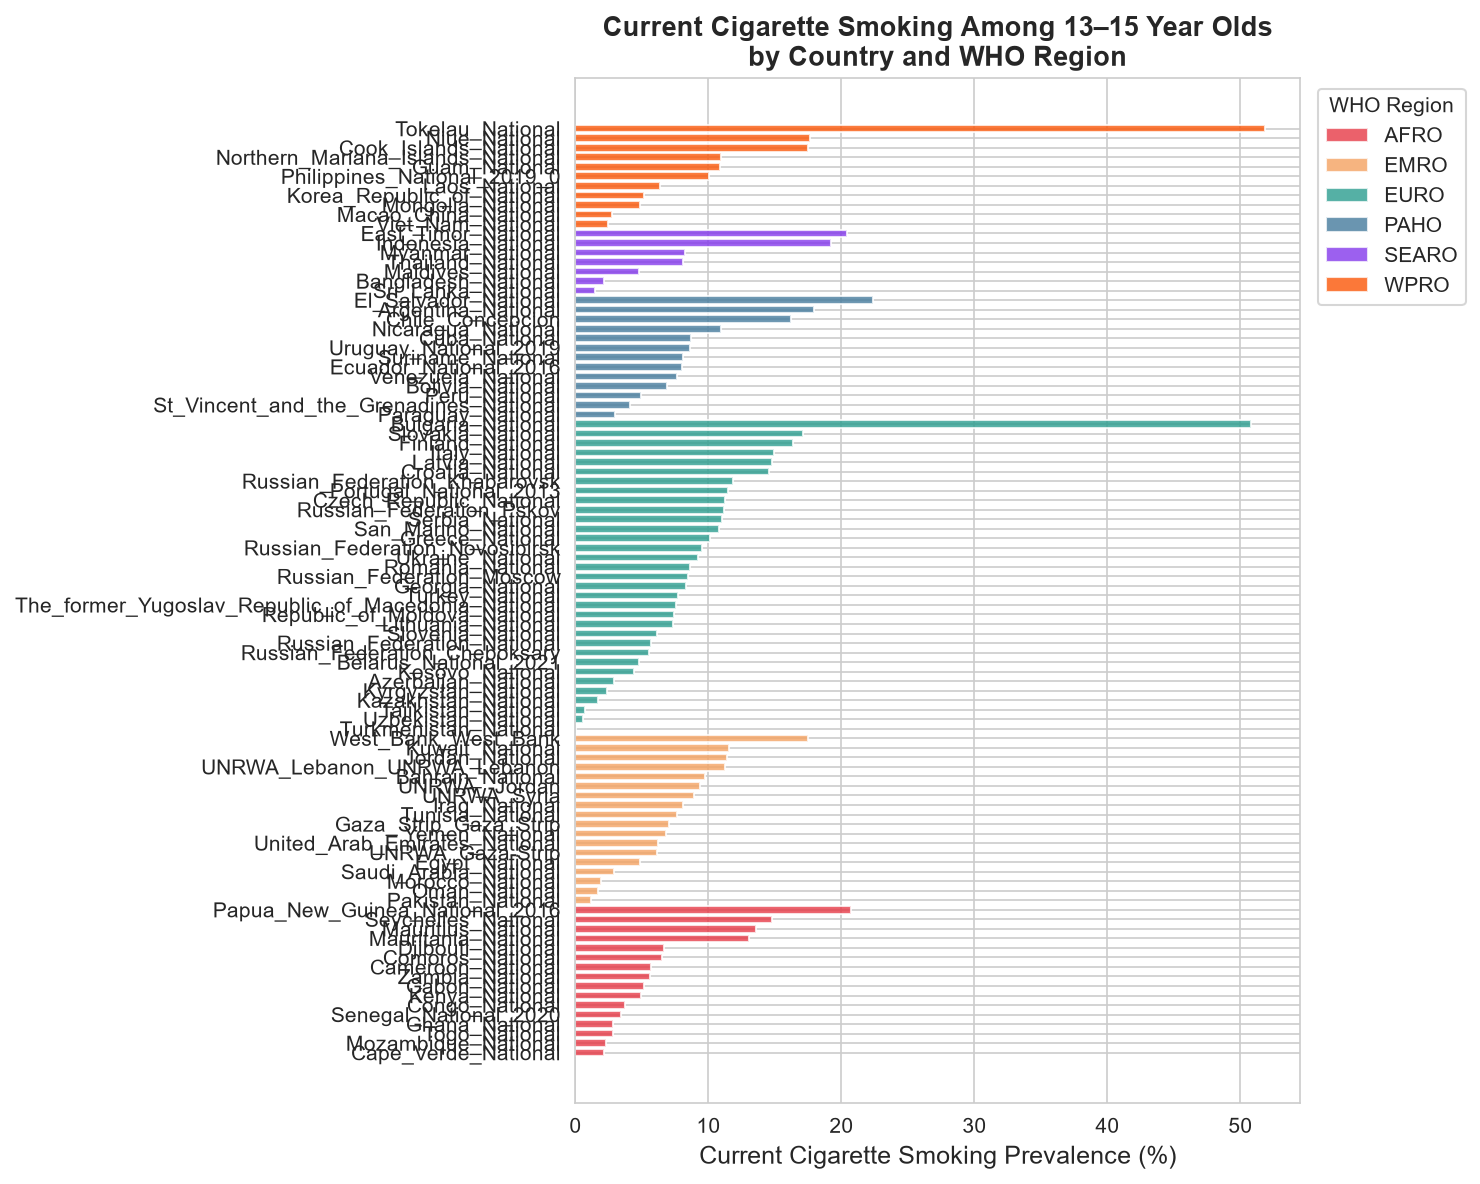

Saved.


In [15]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

csmk = results_df[(results_df['indicator'] == 'CSMK') &
                   results_df['estimate_pct'].notna()].copy()
csmk = csmk.sort_values('estimate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    'AFRO': '#E63946', 'EMRO': '#F4A261', 'EURO': '#2A9D8F',
    'PAHO': '#457B9D', 'SEARO': '#8338EC', 'WPRO': '#FB5607'
}

for region, group in csmk.groupby('region'):
    ax.barh(group['country'], group['estimate_pct'],
            color=colors.get(region, 'gray'), alpha=0.8, label=region)

ax.set_xlabel('Current Cigarette Smoking Prevalence (%)', fontsize=12)
ax.set_title('Current Cigarette Smoking Among 13–15 Year Olds\nby Country and WHO Region',
             fontsize=13, fontweight='bold')
ax.legend(title='WHO Region', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(CLEANED_DIR / "fig1_csmk_by_country.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

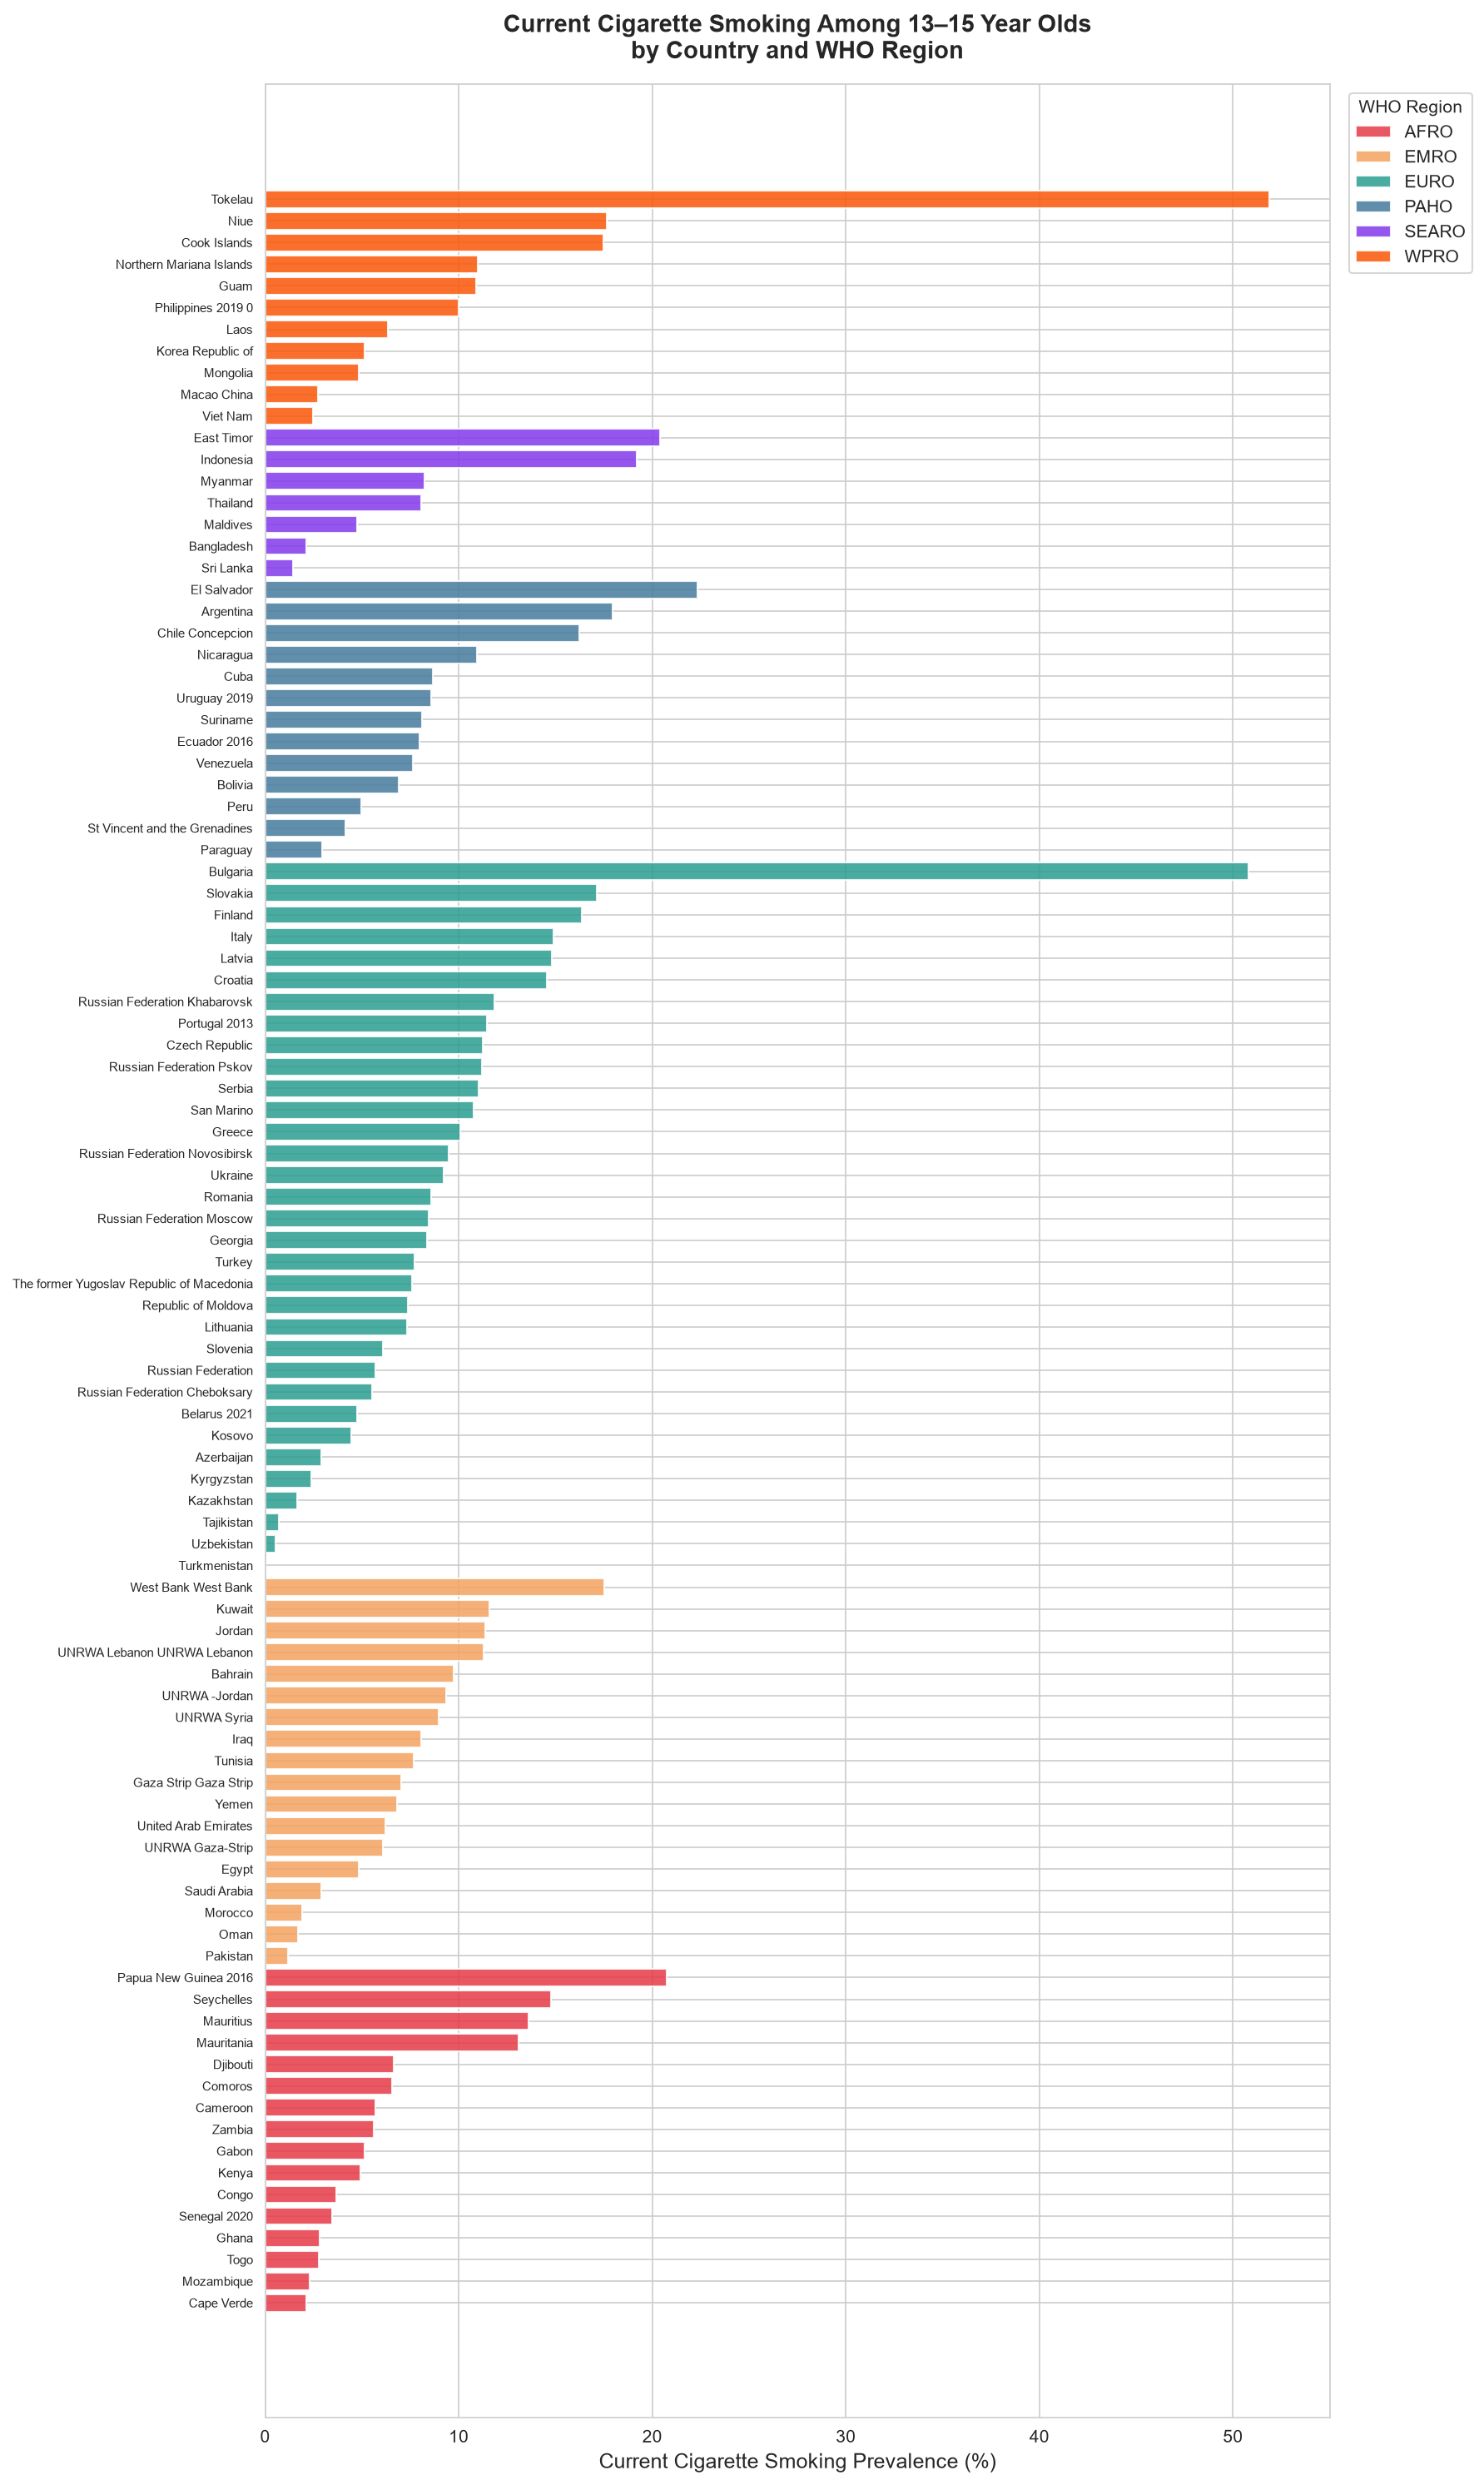

Saved.


In [16]:
fig, ax = plt.subplots(figsize=(12, 20))

csmk['label'] = csmk['country'].str.replace('_National', '').str.replace('_', ' ').str.strip()

colors = {
    'AFRO': '#E63946', 'EMRO': '#F4A261', 'EURO': '#2A9D8F',
    'PAHO': '#457B9D', 'SEARO': '#8338EC', 'WPRO': '#FB5607'
}

for region, group in csmk.groupby('region'):
    ax.barh(group['label'], group['estimate_pct'],
            color=colors.get(region, 'gray'), alpha=0.85, label=region)

ax.set_xlabel('Current Cigarette Smoking Prevalence (%)', fontsize=12)
ax.set_title('Current Cigarette Smoking Among 13–15 Year Olds\nby Country and WHO Region',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=7)
ax.legend(title='WHO Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig(CLEANED_DIR / "fig1_csmk_by_country.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

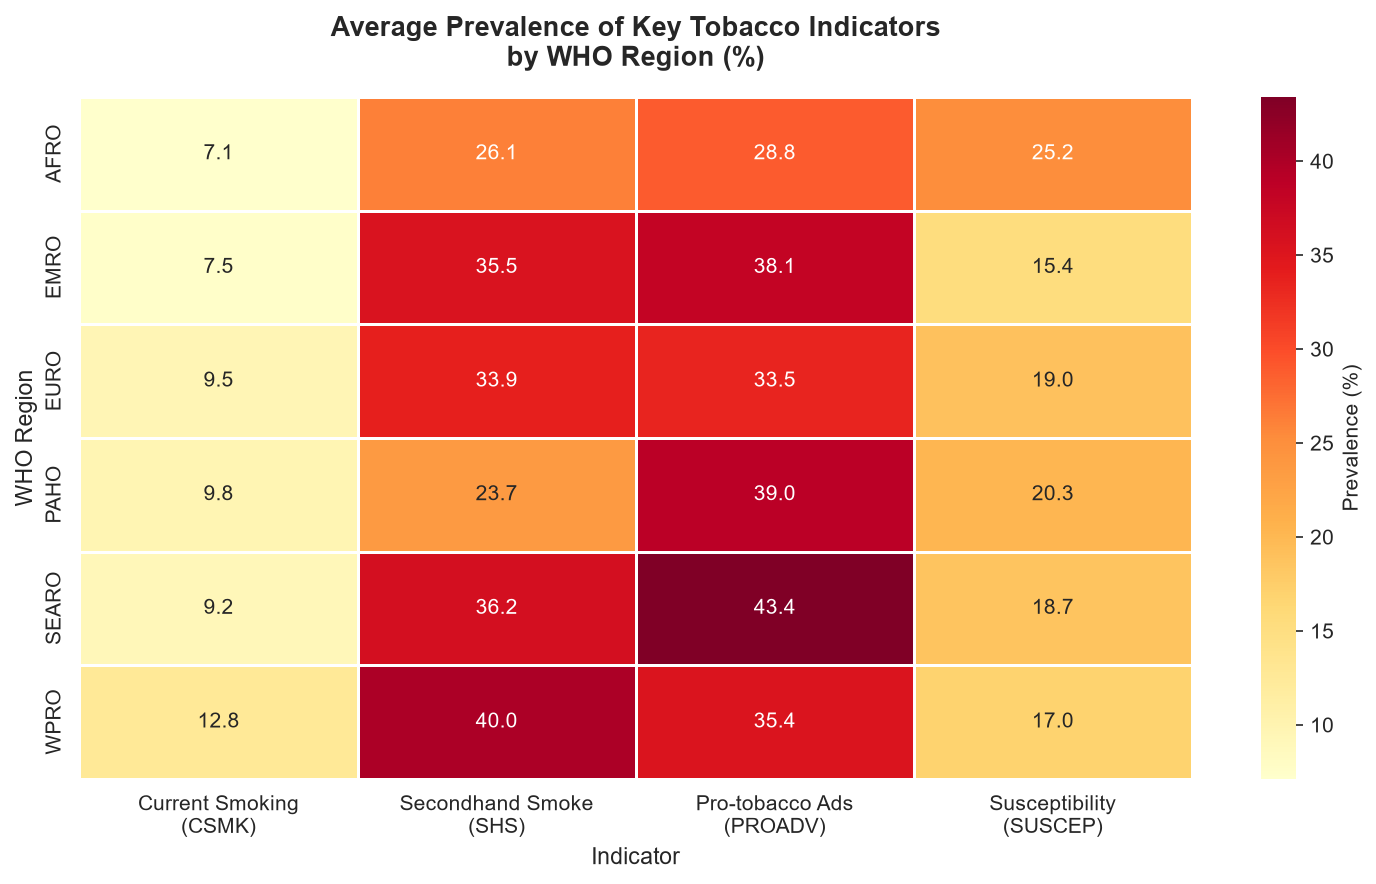

Saved.


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

heatmap_data = results_df.dropna(subset=['estimate_pct']).groupby(
    ['region', 'indicator'])['estimate_pct'].mean().unstack()

heatmap_data = heatmap_data[['CSMK', 'SHS', 'PROADV', 'SUSCEP']]

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Prevalence (%)'},
    ax=ax
)

ax.set_title('Average Prevalence of Key Tobacco Indicators\nby WHO Region (%)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Indicator', fontsize=11)
ax.set_ylabel('WHO Region', fontsize=11)
ax.set_xticklabels(['Current Smoking\n(CSMK)', 'Secondhand Smoke\n(SHS)',
                     'Pro-tobacco Ads\n(PROADV)', 'Susceptibility\n(SUSCEP)'],
                    fontsize=10)
plt.tight_layout()
plt.savefig(CLEANED_DIR / "fig2_heatmap_by_region.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")

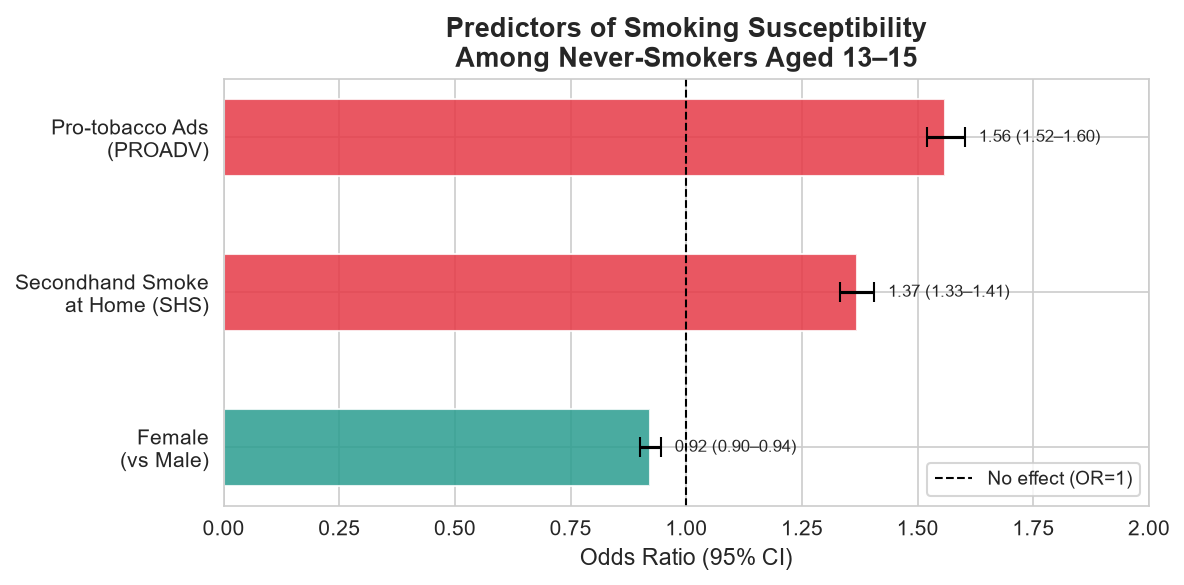

Saved.


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

labels = ['Female\n(vs Male)', 'Secondhand Smoke\nat Home (SHS)',
          'Pro-tobacco Ads\n(PROADV)']
ors   = or_df['Odds Ratio'].values
lci   = or_df['CI Lower'].values
uci   = or_df['CI Upper'].values

xerr_low  = ors - lci
xerr_high = uci - ors

colors_or = ['#2A9D8F' if o < 1 else '#E63946' for o in ors]

ax.barh(labels, ors, xerr=[xerr_low, xerr_high],
        color=colors_or, alpha=0.85, capsize=5, height=0.5)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_xlabel('Odds Ratio (95% CI)', fontsize=11)
ax.set_title('Predictors of Smoking Susceptibility\nAmong Never-Smokers Aged 13–15',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 2.0)

for i, (o, l, u) in enumerate(zip(ors, lci, uci)):
    ax.text(u + 0.03, i, f'{o:.2f} ({l:.2f}–{u:.2f})', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(CLEANED_DIR / "fig3_odds_ratios.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved.")